In [8]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        cross_val_score)
from sklearn.preprocessing     import RobustScaler
from sklearn.ensemble          import RandomForestClassifier, VotingClassifier
from sklearn.decomposition     import PCA
from sklearn.metrics           import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)
print("All imports OK.")

All imports OK.


In [9]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

MODELS_DIR  = "models"
RESULTS_DIR = os.path.join("results", "layer1")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE   = 0.20    # held out completely until Step 5
VAL_SIZE    = 0.10    # used for XGBoost early stopping
RANDOM_SEED = 42
CV_FOLDS    = 5

# Random Forest
RF_N_ESTIMATORS      = 300
RF_MAX_DEPTH         = None   # fully grown = max info from 19 features
RF_MIN_SAMPLES_SPLIT = 5
RF_MIN_SAMPLES_LEAF  = 2

# XGBoost
XGB_N_ESTIMATORS = 300
XGB_MAX_DEPTH    = 8
XGB_LR           = 0.05     # lower lr + more trees = better generalisation
XGB_SUBSAMPLE    = 0.8
XGB_COLSAMPLE    = 0.8

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]
print(f"Config ready. Using {len(APPLICATION_FEATURES)} features.")

Config ready. Using 19 features.


In [10]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns       = df.columns.str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

found   = [f for f in APPLICATION_FEATURES if f in df.columns]
missing = [f for f in APPLICATION_FEATURES if f not in df.columns]
print(f"\nFeatures found   : {len(found)} / {len(APPLICATION_FEATURES)}")
if missing: print(f"Features missing : {missing}")

print("\nClass distribution:")
counts = df[LABEL_COLUMN].value_counts()
for cls, cnt in counts.items():
    bar = chr(9608) * int(30 * cnt / counts.max())
    tag = "  <- BENIGN" if cls == BENIGN_LABEL else ""
    print(f"  {cls:<36}  {cnt:>8,}  {bar}{tag}")

n_b = (df[LABEL_COLUMN] == BENIGN_LABEL).sum()
n_a = (df[LABEL_COLUMN] != BENIGN_LABEL).sum()
print(f"\nBenign : {n_b:,}  ({100*n_b/len(df):.1f}%)")
print(f"Attack : {n_a:,}  ({100*n_a/len(df):.1f}%)")

Rows    : 6,870,587
Columns : 20

Features found   : 19 / 19

Class distribution:
  Benign                                4,122,352  ██████████████████████████████  <- BENIGN
  DDOS attack-HOIC                       686,012  ████
  DDoS attacks-LOIC-HTTP                 576,191  ████
  DoS attacks-Hulk                       461,912  ███
  Bot                                    286,191  ██
  FTP-BruteForce                         193,360  █
  SSH-Bruteforce                         187,589  █
  Infilteration                          161,934  █
  DoS attacks-SlowHTTPTest               139,890  █
  DoS attacks-GoldenEye                   41,508  
  DoS attacks-Slowloris                   10,990  
  DDOS attack-LOIC-UDP                     1,730  
  Brute Force -Web                           611  
  Brute Force -XSS                           230  
  SQL Injection                               87  

Benign : 4,122,352  (60.0%)
Attack : 2,748,235  (40.0%)


In [11]:
X = df[found].values.astype(np.float64)
y = (df[LABEL_COLUMN] != BENIGN_LABEL).astype(int).values  

pd.DataFrame(X, columns=found).describe().T.to_csv(
    os.path.join(RESULTS_DIR, "feature_statistics.csv"))

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_tv)

print(f"{'Split':<12} {'Total':>8}  {'Benign':>8}  {'Attack':>8}  {'Balance':>8}")
print("-" * 55)
for name, X_, y_ in [("Train", X_train, y_train),
                      ("Validation", X_val, y_val),
                      ("Test", X_test, y_test)]:
    nb_ = (y_==0).sum(); na_ = (y_==1).sum()
    print(f"{name:<12} {len(y_):>8,}  {nb_:>8,}  {na_:>8,}  {100*nb_/len(y_):>7.1f}%")

Split           Total    Benign    Attack   Balance
-------------------------------------------------------
Train        4,809,410  2,885,646  1,923,764     60.0%
Validation    687,059   412,235   274,824     60.0%
Test         1,374,118   824,471   549,647     60.0%


In [12]:
scaler    = RobustScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODELS_DIR, "layer1_scaler.pkl"))
print(f"Fitted on {len(X_train):,} training samples")
print(f"Saved -> {MODELS_DIR}/layer1_scaler.pkl")

Fitted on 4,809,410 training samples
Saved -> models/layer1_scaler.pkl


In [13]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)
print(f"Training time : {time.time()-t0:.1f}s")

rf_val = rf.predict(X_val_s)
print(f"Validation Accuracy : {accuracy_score(y_val, rf_val)*100:.2f}%")
print(f"Validation F1       : {f1_score(y_val, rf_val, zero_division=0):.4f}")

skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
cv_acc = cross_val_score(rf, X_train_s, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
cv_f1  = cross_val_score(rf, X_train_s, y_train, cv=skf, scoring="f1",       n_jobs=-1)
print(f"\n{CV_FOLDS}-Fold CV Accuracy : {cv_acc.mean()*100:.2f}% +/- {cv_acc.std()*100:.2f}%")
print(f"{CV_FOLDS}-Fold CV F1       : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

joblib.dump(rf, os.path.join(MODELS_DIR, "layer1_random_forest.pkl"))
print(f"\nSaved -> {MODELS_DIR}/layer1_random_forest.pkl")

Training time : 82.2s
Validation Accuracy : 84.48%
Validation F1       : 0.8323

5-Fold CV Accuracy : 84.51% +/- 0.02%
5-Fold CV F1       : 0.8324 +/- 0.0002

Saved -> models/layer1_random_forest.pkl


In [14]:
n_neg    = int((y_train == 0).sum())
n_pos    = int((y_train == 1).sum())
scale_pw = n_neg / n_pos if n_pos > 0 else 1.0
print(f"scale_pos_weight = {scale_pw:.3f}  (neg={n_neg:,}  pos={n_pos:,})")

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LR,
    subsample=XGB_SUBSAMPLE,
    colsample_bytree=XGB_COLSAMPLE,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=20,
)
xgb.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
print(f"Training time  : {time.time()-t0:.1f}s")
print(f"Best iteration : {xgb.best_iteration}")

xgb_val = xgb.predict(X_val_s)
print(f"Validation Accuracy : {accuracy_score(y_val, xgb_val)*100:.2f}%")
print(f"Validation F1       : {f1_score(y_val, xgb_val, zero_division=0):.4f}")

joblib.dump(xgb, os.path.join(MODELS_DIR, "layer1_xgboost.pkl"))
print(f"\nSaved -> {MODELS_DIR}/layer1_xgboost.pkl")

scale_pos_weight = 1.500  (neg=2,885,646  pos=1,923,764)
Training time  : 129.8s
Best iteration : 299
Validation Accuracy : 84.50%
Validation F1       : 0.8324

Saved -> models/layer1_xgboost.pkl


In [15]:
xgb_ens = XGBClassifier(
    n_estimators=xgb.best_iteration + 1,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LR,
    subsample=XGB_SUBSAMPLE,
    colsample_bytree=XGB_COLSAMPLE,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_ens.fit(X_train_s, y_train)

t0 = time.time()
ensemble = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb_ens)],
    voting="soft",
    n_jobs=-1,
)
ensemble.fit(X_train_s, y_train)
print(f"Training time : {time.time()-t0:.1f}s")

ens_val = ensemble.predict(X_val_s)
print(f"Validation Accuracy : {accuracy_score(y_val, ens_val)*100:.2f}%")
print(f"Validation F1       : {f1_score(y_val, ens_val, zero_division=0):.4f}")

joblib.dump(ensemble, os.path.join(MODELS_DIR, "layer1_voting_ensemble.pkl"))
print(f"\nSaved -> {MODELS_DIR}/layer1_voting_ensemble.pkl")

Training time : 141.7s
Validation Accuracy : 84.51%
Validation F1       : 0.8324

Saved -> models/layer1_voting_ensemble.pkl


In [16]:
results  = []
mdl_list = [("Random Forest",   rf),
            ("XGBoost",         xgb),
            ("Voting Ensemble", ensemble)]

for name, model in mdl_list:
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    acc   = accuracy_score(y_test, preds)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test,    preds, zero_division=0)
    f1    = f1_score(y_test,        preds, zero_division=0)
    try:    auc = roc_auc_score(y_test, proba)
    except: auc = None

    status = "TARGET MET" if acc >= 0.90 else "Below 90%"
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy  : {acc*100:.4f}%   [{status}]")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    if auc: print(f"  ROC-AUC   : {auc:.4f}")
    print()
    print(classification_report(y_test, preds,
                                 target_names=["Benign","Attack"], digits=4))
    results.append({"Model": name,
                    "Accuracy%": round(acc*100, 4),
                    "Precision": round(prec, 4),
                    "Recall"   : round(rec,  4),
                    "F1"       : round(f1,   4),
                    "ROC-AUC"  : round(auc,  4) if auc else "N/A",
                    "90%+ Met" : "Yes" if acc >= 0.90 else "No"})

df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(RESULTS_DIR, "layer1_model_summary.csv"), index=False)
print("\n" + "-"*60)
print(df_results.to_string(index=False))

  Random Forest
  Accuracy  : 84.5207%   [Below 90%]
  Precision : 0.7337
  Recall    : 0.9623
  F1 Score  : 0.8326
  ROC-AUC   : 0.9390

              precision    recall  f1-score   support

      Benign     0.9683    0.7671    0.8561    824471
      Attack     0.7337    0.9623    0.8326    549647

    accuracy                         0.8452   1374118
   macro avg     0.8510    0.8647    0.8443   1374118
weighted avg     0.8745    0.8452    0.8467   1374118

  XGBoost
  Accuracy  : 84.5355%   [Below 90%]
  Precision : 0.7341
  Recall    : 0.9618
  F1 Score  : 0.8327
  ROC-AUC   : 0.9387

              precision    recall  f1-score   support

      Benign     0.9679    0.7677    0.8563    824471
      Attack     0.7341    0.9618    0.8327    549647

    accuracy                         0.8454   1374118
   macro avg     0.8510    0.8648    0.8445   1374118
weighted avg     0.8744    0.8454    0.8468   1374118

  Voting Ensemble
  Accuracy  : 84.5402%   [Below 90%]
  Precision : 0.7340


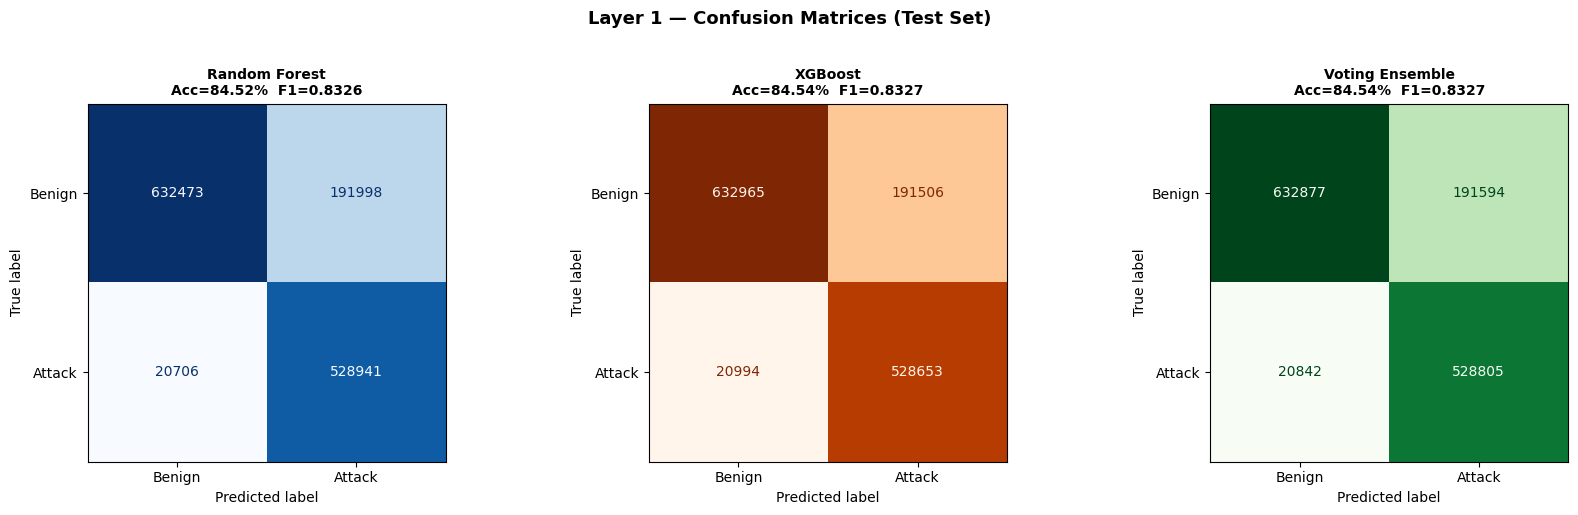

In [17]:
colors = ["steelblue","darkorange","seagreen"]
cmaps  = ["Blues","Oranges","Greens"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (nm, model), cmap in zip(axes, mdl_list, cmaps):
    preds = model.predict(X_test_s)
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, zero_division=0)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                           display_labels=["Benign","Attack"]).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{nm}\nAcc={acc*100:.2f}%  F1={f1:.4f}",
                 fontsize=10, fontweight="bold")
plt.suptitle("Layer 1 — Confusion Matrices (Test Set)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "layer1_confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()

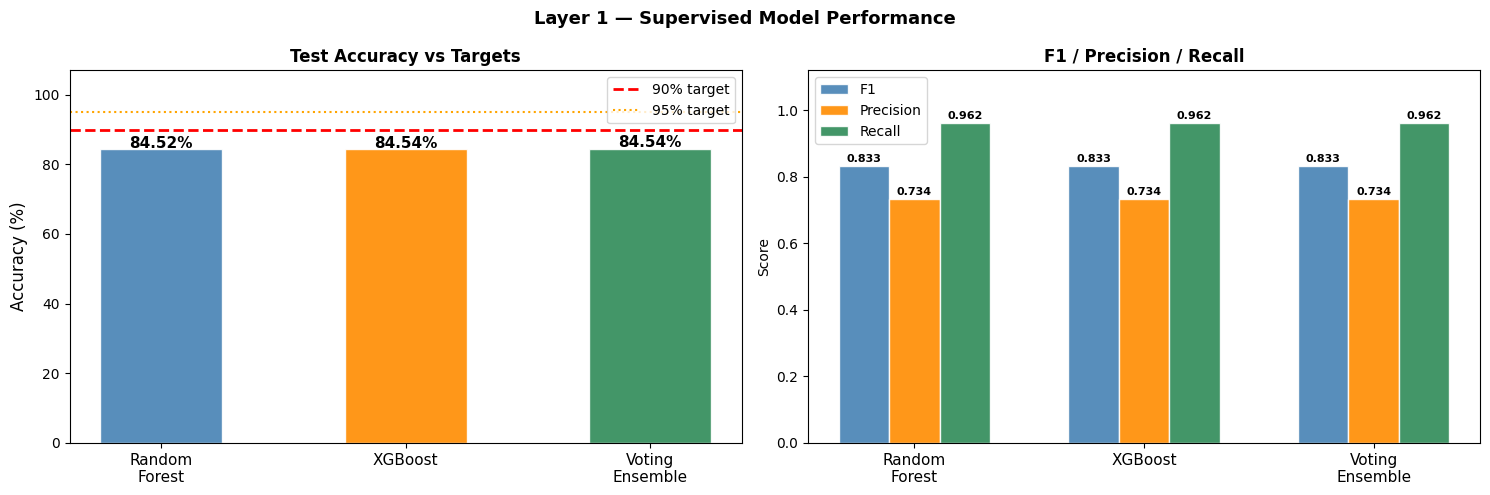

In [18]:
mnames = ["Random\nForest","XGBoost","Voting\nEnsemble"]
accs   = [accuracy_score(y_test, m.predict(X_test_s))*100 for (_, m) in mdl_list]
f1s    = [f1_score(y_test,        m.predict(X_test_s), zero_division=0) for (_, m) in mdl_list]
precs  = [precision_score(y_test, m.predict(X_test_s), zero_division=0) for (_, m) in mdl_list]
recs   = [recall_score(y_test,    m.predict(X_test_s), zero_division=0) for (_, m) in mdl_list]
x, w   = np.arange(3), 0.22

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(x, accs, 0.5, color=colors, edgecolor="white", alpha=0.9)
axes[0].axhline(90, color="red",    linestyle="--", lw=2,   label="90% target")
axes[0].axhline(95, color="orange", linestyle=":",  lw=1.5, label="95% target")
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f"{v:.2f}%", ha="center", fontsize=11, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(mnames, fontsize=11)
axes[0].set_ylim(0,107); axes[0].set_ylabel("Accuracy (%)", fontsize=12)
axes[0].set_title("Test Accuracy vs Targets", fontweight="bold"); axes[0].legend()

for i_, (met, vals, col) in enumerate([("F1",f1s,"steelblue"),
                                         ("Precision",precs,"darkorange"),
                                         ("Recall",recs,"seagreen")]):
    bs = axes[1].bar(x+i_*w, vals, w, label=met, color=col, edgecolor="white", alpha=0.9)
    for b, v in zip(bs, vals):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}",
                     ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[1].set_xticks(x+w); axes[1].set_xticklabels(mnames, fontsize=11)
axes[1].set_ylim(0,1.12); axes[1].set_ylabel("Score"); axes[1].legend()
axes[1].set_title("F1 / Precision / Recall", fontweight="bold")
plt.suptitle("Layer 1 — Supervised Model Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_model_comparison.png"),dpi=150,bbox_inches="tight")
plt.show()

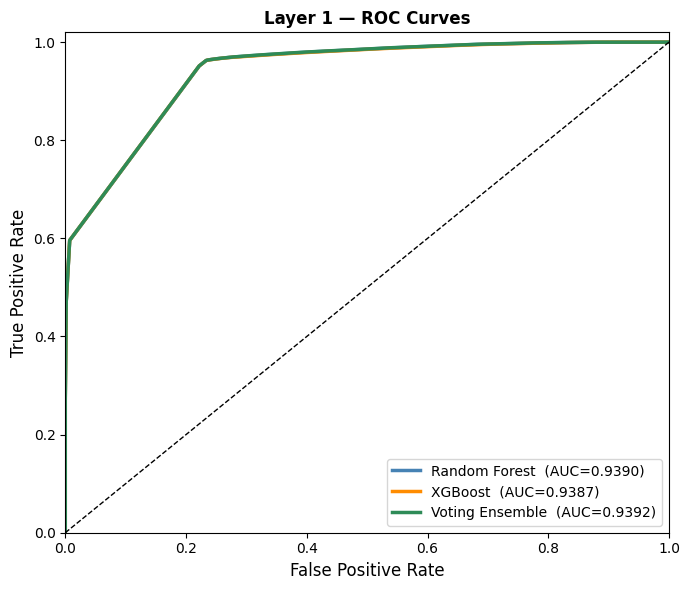

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
for (nm, model), col in zip(mdl_list, colors):
    try:
        proba = model.predict_proba(X_test_s)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=col, lw=2.5, label=f"{nm}  (AUC={auc:.4f})")
    except: pass
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate",fontsize=12); ax.set_ylabel("True Positive Rate",fontsize=12)
ax.set_title("Layer 1 — ROC Curves",fontsize=12,fontweight="bold"); ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_roc_curves.png"),dpi=150,bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for (nm, model), col in zip(mdl_list, colors):
    try:
        proba = model.predict_proba(X_test_s)[:, 1]
        prec_, rec_, _ = precision_recall_curve(y_test, proba)
        ap = float(np.trapz(prec_[::-1], rec_[::-1]))
        ax.plot(rec_, prec_, color=col, lw=2.5, label=f"{nm}  (AP={ap:.4f})")
    except: pass
ax.set_xlabel("Recall",fontsize=12); ax.set_ylabel("Precision",fontsize=12)
ax.set_title("Layer 1 — Precision-Recall Curves",fontsize=12,fontweight="bold")
ax.legend(fontsize=10); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_pr_curves.png"),dpi=150,bbox_inches="tight")
plt.show()

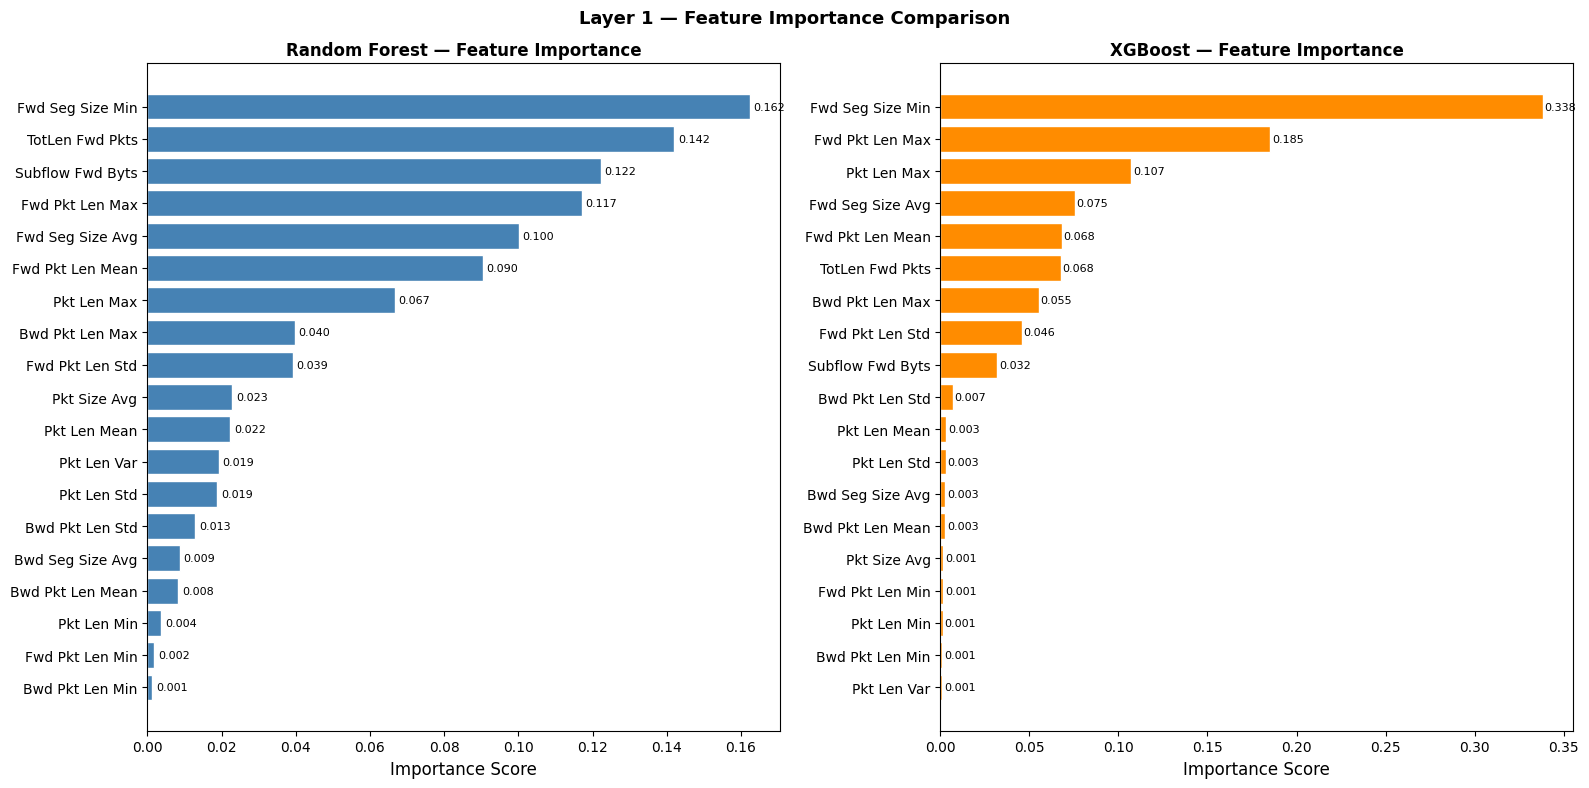

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (nm, model), col in zip(axes,
        [("Random Forest", rf), ("XGBoost", xgb)],
        ["steelblue","darkorange"]):
    imp = model.feature_importances_
    idx = np.argsort(imp)
    bs  = ax.barh([found[i] for i in idx], imp[idx], color=col, edgecolor="white")
    for b, v in zip(bs, imp[idx]):
        ax.text(v+0.001, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlabel("Importance Score",fontsize=12)
    ax.set_title(f"{nm} — Feature Importance",fontsize=12,fontweight="bold")
plt.suptitle("Layer 1 — Feature Importance Comparison",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_feature_importance.png"),dpi=150,bbox_inches="tight")
plt.show()

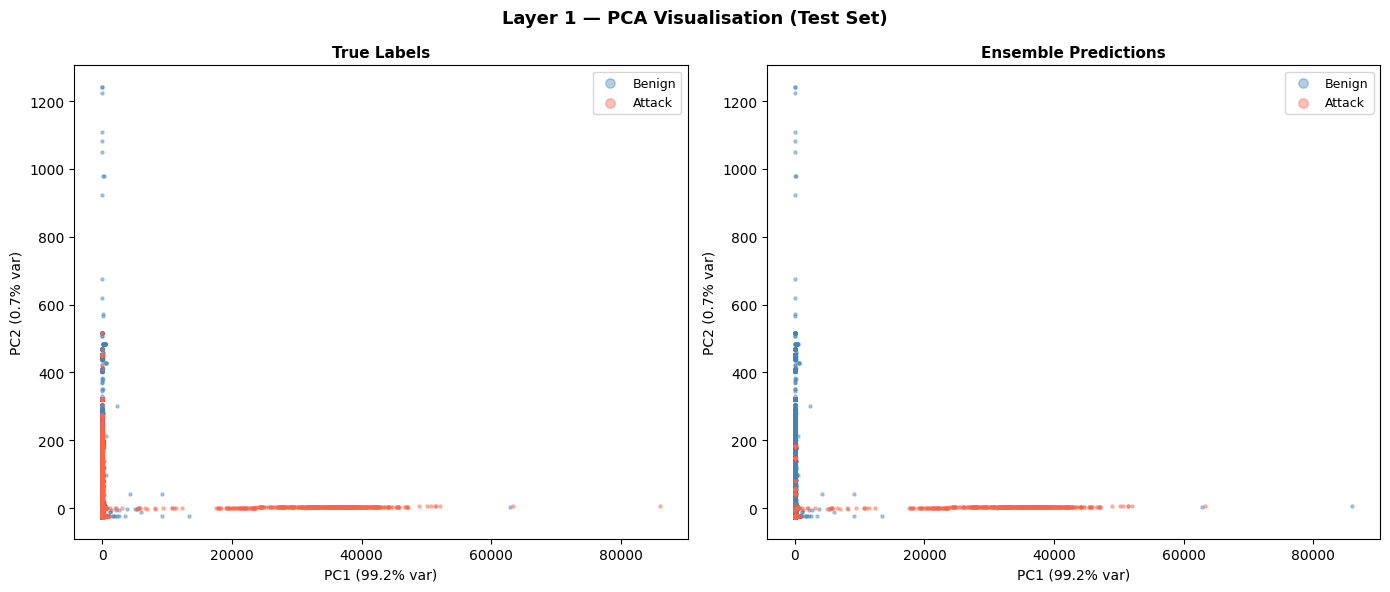

In [22]:
pca      = PCA(n_components=2, random_state=RANDOM_SEED)
X2d      = pca.fit_transform(X_test_s)
var      = pca.explained_variance_ratio_
ens_pred = ensemble.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (lbl, title) in zip(axes, [(y_test,"True Labels"),(ens_pred,"Ensemble Predictions")]):
    ax.scatter(X2d[lbl==0,0], X2d[lbl==0,1], c="steelblue", s=5, alpha=0.4, label="Benign")
    ax.scatter(X2d[lbl==1,0], X2d[lbl==1,1], c="tomato",    s=5, alpha=0.4, label="Attack")
    ax.set_xlabel(f"PC1 ({100*var[0]:.1f}% var)",fontsize=10)
    ax.set_ylabel(f"PC2 ({100*var[1]:.1f}% var)",fontsize=10)
    ax.set_title(title,fontsize=11,fontweight="bold"); ax.legend(markerscale=3,fontsize=9)
plt.suptitle("Layer 1 — PCA Visualisation (Test Set)",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_pca_visualisation.png"),dpi=150,bbox_inches="tight")
plt.show()

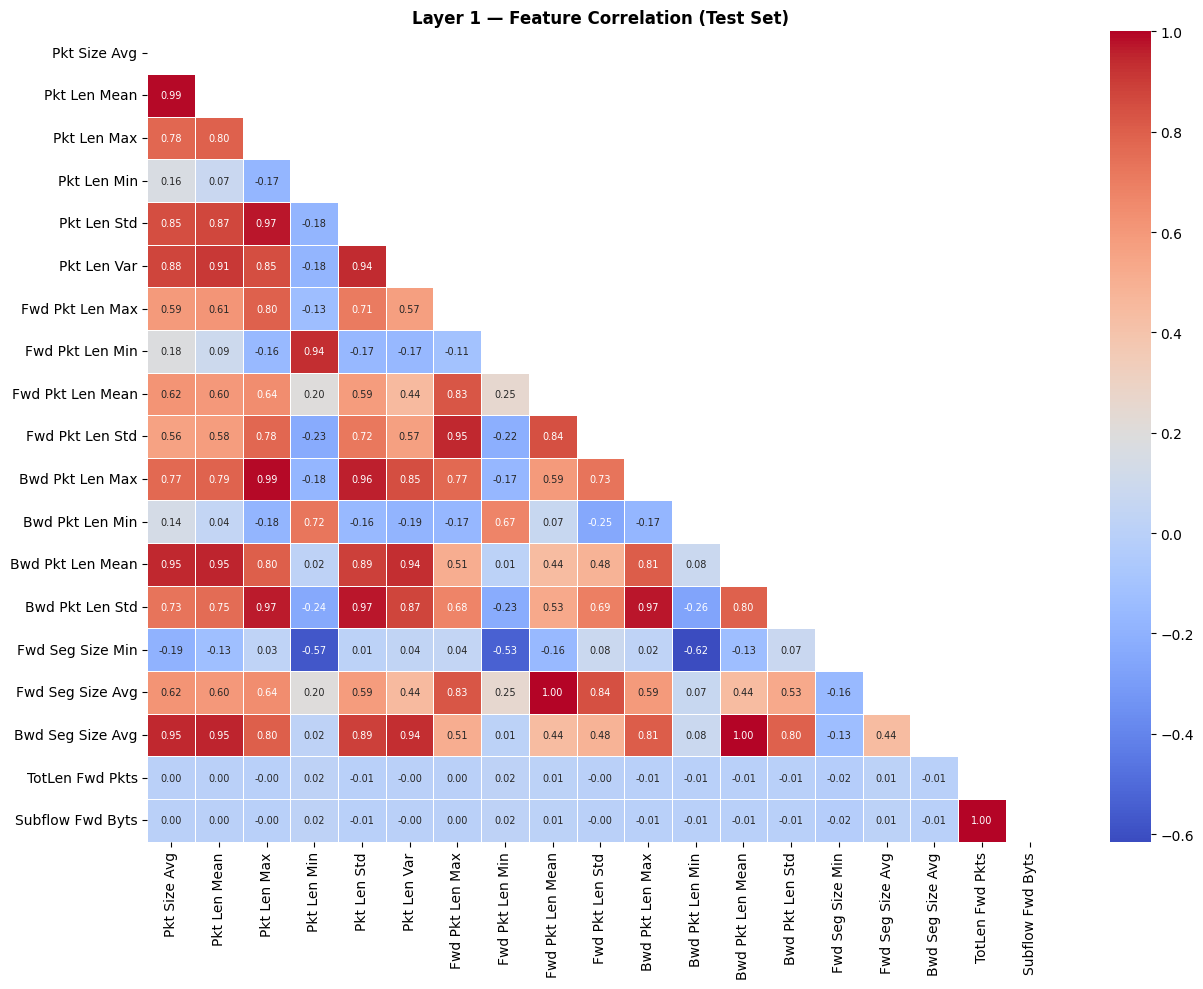

In [23]:
n_feat = len(found)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(pd.DataFrame(X_test_s, columns=found).corr(),
            mask=np.triu(np.ones((n_feat,n_feat),dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, annot_kws={"size":7})
ax.set_title("Layer 1 — Feature Correlation (Test Set)",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_feature_correlation.png"),dpi=150,bbox_inches="tight")
plt.show()

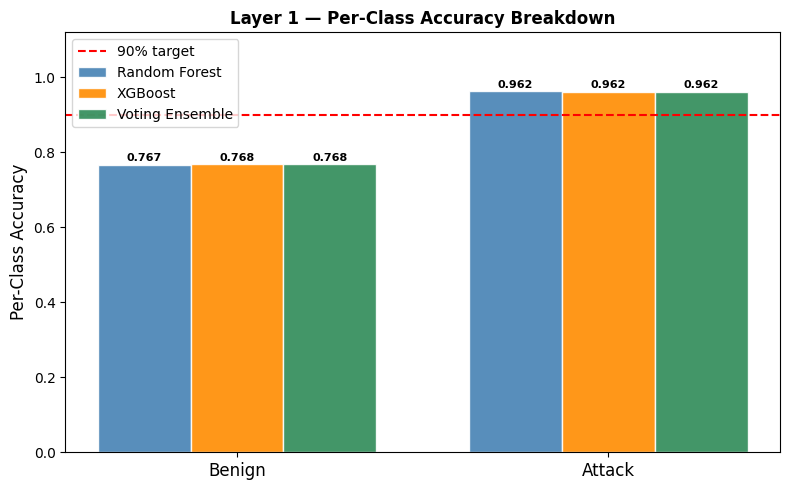

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
x8, w8  = np.arange(2), 0.25
for i_, (nm, model) in enumerate(mdl_list):
    preds   = model.predict(X_test_s)
    cls_acc = [float((preds[y_test==c]==c).mean()) if (y_test==c).sum()>0 else 0
               for c in [0, 1]]
    bs = ax.bar(x8+i_*w8, cls_acc, w8, label=nm,
                color=colors[i_], edgecolor="white", alpha=0.9)
    for b, v in zip(bs, cls_acc):
        ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.axhline(0.90, color="red", linestyle="--", lw=1.5, label="90% target")
ax.set_xticks(x8+w8); ax.set_xticklabels(["Benign","Attack"],fontsize=12)
ax.set_ylim(0,1.12); ax.set_ylabel("Per-Class Accuracy",fontsize=12)
ax.set_title("Layer 1 — Per-Class Accuracy Breakdown",fontsize=12,fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer1_per_class_accuracy.png"),dpi=150,bbox_inches="tight")
plt.show()

In [ ]:
best_idx  = df_results["Accuracy%"].idxmax()
best_name = df_results.loc[best_idx, "Model"]
best_acc  = float(df_results.loc[best_idx, "Accuracy%"])

cfg = {
    "approach"         : "supervised",
    "best_model"       : best_name,
    "best_accuracy_%"  : best_acc,
    "best_f1"          : float(df_results.loc[best_idx, "F1"]),
    "label_column"     : LABEL_COLUMN,
    "benign_label"     : BENIGN_LABEL,
    "features"         : found,
    "90pct_target_met" : best_acc >= 90.0,
}
with open(os.path.join(MODELS_DIR, "layer1_config.json"), "w") as fh:
    json.dump(cfg, fh, indent=2)

print(f"Best model  : {best_name}  ({best_acc:.4f}%)")
print()
print("Models saved in models/:")
for f in ["layer1_scaler.pkl","layer1_random_forest.pkl",
          "layer1_xgboost.pkl","layer1_voting_ensemble.pkl","layer1_config.json"]:
    print(f"  {f}")
print("\nResults saved in results/layer1/:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {f}")
print("\nNext -> run  notebook_02_layer2_known_unknown.ipynb")

90% Accuracy Target : NOT YET MET
Best model  : Voting Ensemble  (84.5402%)

Models saved in models/:
  layer1_scaler.pkl
  layer1_random_forest.pkl
  layer1_xgboost.pkl
  layer1_voting_ensemble.pkl
  layer1_config.json

Results saved in results/layer1/:
  feature_statistics.csv
  layer1_confusion_matrices.png
  layer1_feature_correlation.png
  layer1_feature_importance.png
  layer1_model_comparison.png
  layer1_model_summary.csv
  layer1_pca_visualisation.png
  layer1_per_class_accuracy.png
  layer1_pr_curves.png
  layer1_roc_curves.png

Next -> run  notebook_02_layer2_known_unknown.ipynb
